<a href="https://colab.research.google.com/github/kazuma543/GOLF_AI/blob/main/YOLO_GOlf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pwd

In [ ]:
cd /content/drive/MyDrive/Ass3/YOLO_partc

In [ ]:
!git clone https://github.com/ultralytics/yolov5

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.0 MB/s eta 0:00:00


In [ ]:
import zipfile
from pathlib import Path




output_dir = "/content/drive/MyDrive/Ass3/YOLO_partc/dataset"



image_zip = "/content/drive/MyDrive/Ass3/YOLO_partc/val_img.zip"
with zipfile.ZipFile(image_zip, "r") as zf:
    zf.extractall(output_dir)
print(f"unzipped")


images = list(Path(output_dir).rglob("*.jpg"))

print(f"image number: {len(images)}")


In [ ]:
import zipfile
from pathlib import Path



output_dir = "/content/drive/MyDrive/Ass3/YOLO_partc/dataset"



image_zip = "/content/drive/MyDrive/Ass3/YOLO_partc/train_img.zip"
with zipfile.ZipFile(image_zip, "r") as zf:
    zf.extractall(output_dir)
print(f"unzipped")


images = list(Path(output_dir).rglob("*.jpg"))

print(f"image number: {len(images)}")


In [ ]:
import shutil
from pathlib import Path


label_dir = Path("/content/drive/MyDrive/Ass3/YOLO_partc/dataset/obj_train_data/train 5")

frame_dir = Path("/content/drive/MyDrive/Ass3/YOLO_partc/dataset/val/train")


matched = 0
missing = 0

for lbl in label_dir.glob("*.txt"):
    img_name = lbl.stem + ".jpg"

    img_src = list(frame_dir.rglob(img_name))

    if img_src:
        shutil.copy(img_src[0], label_dir / img_name)
        matched += 1
    else:
        missing += 1

print(f"complet copy: {matched}")
print(f"cant find: {missing}")

In [ ]:
import zipfile
zip_path = "/content/drive/MyDrive/Ass3/YOLO_partc/train.zip"
zip_path = "/content/drive/MyDrive/Ass3/YOLO_partc/val.zip"
extract_dir = "/content/drive/MyDrive/Ass3/YOLO_partc/dataset"

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

In [ ]:
pip install pyyaml

In [ ]:
dataset_dir = "/content/drive/MyDrive/Ass3/YOLO_partc/dataset"

yaml_content = f"""
train: {dataset_dir}/train.txt
val: {dataset_dir}/val1

nc: 1
names: ['golf_club']
"""

with open(f"{dataset_dir}/dataset.yaml", "w") as f:
    f.write(yaml_content)

print("dataset.yaml")

In [ ]:
from pathlib import Path

val_dir = Path("/content/drive/MyDrive/Ass3/YOLO_partc/dataset/obj_train_data/val")

images = list(val_dir.glob("*.jpg"))
labels = list(val_dir.glob("*.txt"))

print(f"number of image: {len(images)}")
print(f"number of label: {len(labels)}")

In [ ]:
cd /content/drive/MyDrive/Ass3/YOLO_partc/yolov5/

In [ ]:
pwd

In [ ]:
#image detection
import os

cache = Path(f"{dataset_dir}/train.cache")
if cache.exists():
    cache.unlink()
    print("delete cache")
os.chdir("/content/drive/MyDrive/Ass3/YOLO_partc/yolov5")

!python train.py \
    --img 416 \
    --batch 16 \
    --epochs 200 \
    --data "/content/drive/MyDrive/Ass3/YOLO_partc/dataset/new_data_yaml" \
    --weights yolov5s.pt \
    --name golf_club_only \
    --patience 30 \
    --save-period 20 \
    --cos-lr

In [ ]:
# video detection v2
!python detect.py \
    --weights runs/train/golf_club_only44/weights/best.pt \
    --source "/content/drive/MyDrive/9.mp4" \
    --img 416 \
    --conf 0.15 \
    --iou-thres 0.45 \
    --augment \
    --name golf_club_result \
    --exist-ok

detect: weights=['runs/train/golf_club_only44/weights/best.pt'], source=/content/drive/MyDrive/9.mp4, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.15, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=True, visualize=False, update=False, project=runs/detect, name=golf_club_result, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0

In [ ]:
#save good swing orbit
import cv2
import torch
import numpy as np
import os

os.chdir("/content/drive/MyDrive/Ass3/YOLO_partc/yolov5")

model = torch.hub.load(
    "/content/drive/MyDrive/Ass3/YOLO_partc/yolov5",
    "custom",
    path="runs/train/golf_club_only44/weights/best.pt",
    source="local"
)
model.conf = 0.15


good_video_path = "/content/drive/MyDrive/Ass3/front_angle_video/28.mp4"

cap = cv2.VideoCapture(good_video_path)
good_trajectory = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = model(rgb)
    det = results.xyxy[0]

    if len(det) > 0:
        x1, y1, x2, y2, conf, cls = det[0].tolist()
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)
        good_trajectory.append((cx, cy))

cap.release()

np.save("/content/drive/MyDrive/Ass3/good_trajectory.npy", np.array(good_trajectory))
print(f"Good swing orbit: {len(good_trajectory)}flames")

requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
error: Failed to parse: `urllib3>=2.6.0 ; python_version > 3.8`
  Caused by: Expected a quoted string or a valid marker name, found `3.8`
urllib3>=2.6.0 ; python_version > 3.8
            

YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated.

Good swing orbit: 195flames


/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [ ]:
#compare to test swing
!pip install fastdtw
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean


good_traj = np.load("/content/drive/MyDrive/Ass3/good_trajectory.npy")


test_video_path = "/content/drive/MyDrive/210.mp4"
cap = cv2.VideoCapture(test_video_path)
test_trajectory = []

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "/content/drive/MyDrive/Ass3/swing_result1.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h)
)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = model(rgb)
    det = results.xyxy[0]

    if len(det) > 0:
        x1, y1, x2, y2, conf, cls = det[0].tolist()
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)
        test_trajectory.append((cx, cy))


        for i in range(1, len(test_trajectory)):
            cv2.line(frame, test_trajectory[i-1], test_trajectory[i], (0, 255, 255), 2)
        cv2.circle(frame, (cx, cy), 5, (0, 255, 0), -1)

    out.write(frame)

cap.release()
out.release()


test_traj = np.array(test_trajectory)
distance, _ = fastdtw(good_traj, test_traj, dist=euclidean)


threshold = 5000
if distance < threshold:
    verdict = "Good Swing"
else:
    verdict = "Bad Swing"

print(f"Judge: {verdict}")
print(f"Score: {distance:.1f}")
print(f"（Low score = good swing）")

Judge: Good Swing
Score: 0.0
（Low score = good swing）


In [ ]:
# Visualise
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(good_traj[:, 0], good_traj[:, 1],
         color="green", label="Good swing", linewidth=2)
plt.plot(test_traj[:, 0], test_traj[:, 1],
         color="red", label="Test swing", linewidth=2)
plt.gca().invert_yaxis()
plt.legend()
plt.title(f"Swing orbit compare\nscore: {distance:.1f} → {verdict}")
plt.xlabel("X")
plt.ylabel("Y")
plt.savefig("/content/drive/MyDrive/Ass3/trajectory_comparison.png", dpi=150)
plt.show()

In [ ]:
#extract test swting
import cv2
import torch
import numpy as np
import os

os.chdir("/content/drive/MyDrive/Ass3/YOLO_partc/yolov5")

model = torch.hub.load(
    "/content/drive/MyDrive/Ass3/YOLO_partc/yolov5",
    "custom",
    path="runs/train/golf_club_only44/weights/best.pt",
    source="local"
)
model.conf = 0.15


cap = cv2.VideoCapture("/content/drive/MyDrive/9.mp4")
test_trajectory = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = model(rgb)
    det = results.xyxy[0]

    if len(det) > 0:
        x1, y1, x2, y2, conf, cls = det[0].tolist()
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)
        test_trajectory.append((cx, cy))

cap.release()


np.save("/content/drive/MyDrive/Ass3/test_trajectory.npy", np.array(test_trajectory))
print(f"test orbit saved: {len(test_trajectory)}flames")

requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
error: Failed to parse: `urllib3>=2.6.0 ; python_version > 3.8`
  Caused by: Expected a quoted string or a valid marker name, found `3.8`
urllib3>=2.6.0 ; python_version > 3.8
            

YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated.

test orbit saved: 82flames


/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt

good_traj = np.load("/content/drive/MyDrive/Ass3/good_trajectory.npy", allow_pickle=True).astype(float)
test_traj = np.load("/content/drive/MyDrive/Ass3/test_trajectory.npy", allow_pickle=True).astype(float)

def remove_outliers(traj, threshold=30):

    cleaned = [traj[0]]
    for i in range(1, len(traj)):
        dist = np.linalg.norm(traj[i] - cleaned[-1])
        if dist < threshold:
            cleaned.append(traj[i])
    return np.array(cleaned)

def smooth(traj, sigma=3):
    x = gaussian_filter1d(traj[:, 0], sigma)
    y = gaussian_filter1d(traj[:, 1], sigma)
    return np.stack([x, y], axis=1)

def normalize(traj):
    traj = traj.copy()
    for i in range(2):
        mn, mx = traj[:, i].min(), traj[:, i].max()
        traj[:, i] = (traj[:, i] - mn) / (mx - mn + 1e-6)
    return traj


good = normalize(smooth(remove_outliers(good_traj)))
test = normalize(smooth(remove_outliers(test_traj)))

print(f"Good swing: {len(good)}flame")
print(f"test swing: {len(test)}flame")


distance, _ = fastdtw(good, test, dist=euclidean)
threshold = 2.0
verdict = "✅ Good Swing" if distance < threshold else "❌ Bad Swing"

print(f"Judge: {verdict}")
print(f"score: {distance:.3f}")


plt.figure(figsize=(8, 6))
plt.plot(good[:, 0], good[:, 1], color="green", label="Good swing", linewidth=2)
plt.plot(test[:, 0], test[:, 1], color="red", label="Test swing", linewidth=2)
plt.gca().invert_yaxis()
plt.legend()
plt.title(f"compare orbit{verdict}  score: {distance:.3f}")
plt.savefig("/content/drive/MyDrive/Ass3/trajectory_fixed.png", dpi=150)
plt.show()

Good swing: 63flame
test swing: 56flame
Judge: ❌ Bad Swing
score: 4.348


In [ ]:
#upgrade threshold
import numpy as np
from scipy.ndimage import gaussian_filter1d
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt

good_traj = np.load("/content/drive/MyDrive/Ass3/good_trajectory.npy", allow_pickle=True).astype(float)
test_traj = np.load("/content/drive/MyDrive/Ass3/test_trajectory.npy", allow_pickle=True).astype(float)

def remove_outliers(traj, threshold=30):
    cleaned = [traj[0]]
    for i in range(1, len(traj)):
        dist = np.linalg.norm(traj[i] - cleaned[-1])
        if dist < threshold:
            cleaned.append(traj[i])
    return np.array(cleaned)

def smooth(traj, sigma=3):
    x = gaussian_filter1d(traj[:, 0], sigma)
    y = gaussian_filter1d(traj[:, 1], sigma)
    return np.stack([x, y], axis=1)

def normalize(traj):
    traj = traj.copy()
    for i in range(2):
        mn, mx = traj[:, i].min(), traj[:, i].max()
        traj[:, i] = (traj[:, i] - mn) / (mx - mn + 1e-6)
    return traj

good = normalize(smooth(remove_outliers(good_traj)))
test = normalize(smooth(remove_outliers(test_traj)))

distance, _ = fastdtw(good, test, dist=euclidean)

if distance < 5.0:
    verdict = "✅ Good Swing"
    comment = "Good Swing"
elif distance < 10.0:
    verdict = "⚠️ Average Swing"
    comment = "Almost there"
else:
    verdict = "❌ Bad Swing"
    comment = "Check your form"

print(f"Judge: {verdict}")
print(f"Comment: {comment}")
print(f"Score: {distance:.3f}")


plt.figure(figsize=(8, 6))
plt.plot(good[:, 0], good[:, 1], color="green", label="Good swing", linewidth=2)
plt.plot(test[:, 0], test[:, 1], color="red", label="Test swing", linewidth=2)
plt.gca().invert_yaxis()
plt.legend()
plt.title(f"{verdict}\nScore: {distance:.3f}  {comment}")
plt.savefig("/content/drive/MyDrive/Ass3/final_result.png", dpi=150)
plt.show()

Judge: ✅ Good Swing
Comment: Good Swing
Score: 4.348


In [ ]:
#extract test swing
import cv2
import torch
import numpy as np
import os

os.chdir("/content/drive/MyDrive/Ass3/YOLO_partc/yolov5")

model = torch.hub.load(
    "/content/drive/MyDrive/Ass3/YOLO_partc/yolov5",
    "custom",
    path="runs/train/golf_club_only44/weights/best.pt",
    source="local"
)
model.conf = 0.15


cap = cv2.VideoCapture("/content/drive/MyDrive/Ass3/front_angle_video/804.mp4")
test_trajectory = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = model(rgb)
    det = results.xyxy[0]

    if len(det) > 0:
        x1, y1, x2, y2, conf, cls = det[0].tolist()
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)
        test_trajectory.append((cx, cy))

cap.release()


np.save("/content/drive/MyDrive/Ass3/test_trajectory.npy", np.array(test_trajectory))
print(f"test orbit saved: {len(test_trajectory)}flames")

requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
error: Failed to parse: `urllib3>=2.6.0 ; python_version > 3.8`
  Caused by: Expected a quoted string or a valid marker name, found `3.8`
urllib3>=2.6.0 ; python_version > 3.8
            

YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated.

test orbit saved: 208flames


/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/models/common.py:900: FutureWarning: `torch.cuda.amp.autocast(args

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt

good_traj = np.load("/content/drive/MyDrive/Ass3/good_trajectory.npy", allow_pickle=True).astype(float)
test_traj = np.load("/content/drive/MyDrive/Ass3/test_trajectory.npy", allow_pickle=True).astype(float)

def remove_outliers(traj, threshold=80):
    cleaned = [traj[0]]
    for i in range(1, len(traj)):
        dist = np.linalg.norm(traj[i] - cleaned[-1])
        if dist < threshold:
            cleaned.append(traj[i])
    return np.array(cleaned)

def smooth(traj, sigma=2):
    x = gaussian_filter1d(traj[:, 0], sigma)
    y = gaussian_filter1d(traj[:, 1], sigma)
    return np.stack([x, y], axis=1)

def normalize(traj):
    traj = traj.copy()
    for i in range(2):
        mn, mx = traj[:, i].min(), traj[:, i].max()
        traj[:, i] = (traj[:, i] - mn) / (mx - mn + 1e-6)
    return traj

good = normalize(smooth(remove_outliers(good_traj)))
test = normalize(smooth(remove_outliers(test_traj)))

print(f"Good swing: {len(good)}frames")
print(f"Test swing: {len(test)}frames")

distance, _ = fastdtw(good, test, dist=euclidean)

if distance < 30.0:
    verdict = "✅ Good Swing"
    comment = "Nice Swing"
elif distance < 50.0:
    verdict = "⚠️ Average Swing"
    comment = "Almost there"
else:
    verdict = "❌ Bad Swing"
    comment = "Check your form"

print(f"\njudge: {verdict}")
print(f"Comment: {comment}")
print(f"score: {distance:.3f}")


plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(good[:, 0], good[:, 1], color="green", linewidth=2, marker="o", markersize=2)
plt.gca().invert_yaxis()
plt.title(f"Good Swing ({len(good)}frames)")

plt.subplot(1, 3, 2)
plt.plot(test[:, 0], test[:, 1], color="red", linewidth=2, marker="o", markersize=2)
plt.gca().invert_yaxis()
plt.title(f"Test Swing ({len(test)}frames)")

plt.subplot(1, 3, 3)
plt.plot(good[:, 0], good[:, 1], color="green", linewidth=2, label="Good")
plt.plot(test[:, 0], test[:, 1], color="red", linewidth=2, label="Test")
plt.gca().invert_yaxis()
plt.legend()
plt.title(f"{verdict}\nScore: {distance:.3f}")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Ass3/final_result.png", dpi=150)
plt.show()

ModuleNotFoundError: No module named 'fastdtw'

In [ ]:
!pip install fastapi uvicorn python-multipart fastdtw nest-asyncio
!npm install -g localtunnel

import nest_asyncio
nest_asyncio.apply()
import base64
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
import uvicorn, torch, cv2, numpy as np
import os, tempfile, subprocess, time, threading
from scipy.ndimage import gaussian_filter1d
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

os.chdir("/content/drive/MyDrive/Ass3/YOLO_partc/yolov5")
model = torch.hub.load(
    "/content/drive/MyDrive/Ass3/YOLO_partc/yolov5",
    "custom",
    path="runs/train/golf_club_only44/weights/best.pt",
    source="local"
)
model.conf = 0.15
good_traj = np.load("/content/drive/MyDrive/Ass3/good_trajectory.npy", allow_pickle=True).astype(float)

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

def process(traj, threshold=80, sigma=2):
    cleaned = [traj[0]]
    for i in range(1, len(traj)):
        if np.linalg.norm(traj[i] - cleaned[-1]) < threshold:
            cleaned.append(traj[i])
    traj = np.array(cleaned, dtype=float)
    x = gaussian_filter1d(traj[:, 0], sigma)
    y = gaussian_filter1d(traj[:, 1], sigma)
    traj = np.stack([x, y], axis=1)
    for i in range(2):
        mn, mx = traj[:, i].min(), traj[:, i].max()
        traj[:, i] = (traj[:, i] - mn) / (mx - mn + 1e-6)
    return traj

def extract_trajectory(video_path):
    cap = cv2.VideoCapture(video_path)
    trajectory = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = model(rgb)
        det = results.xyxy[0]
        if len(det) > 0:
            x1, y1, x2, y2, conf, cls = det[0].tolist()
            trajectory.append((int((x1+x2)/2), int((y1+y2)/2)))
    cap.release()
    return np.array(trajectory)

@app.post("/analyze")
async def analyze(file: UploadFile = File(...)):
    with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as tmp:
        tmp.write(await file.read())
        tmp_path = tmp.name
    try:

        cap = cv2.VideoCapture(tmp_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames_b64 = []

        for t in [0.1, 0.5, 0.9]:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(total * t))
            ret, frame = cap.read()
            if ret:
                _, buf = cv2.imencode(".jpg", frame)
                b64 = base64.b64encode(buf).decode("utf-8")
                frames_b64.append(f"data:image/jpeg;base64,{b64}")
        cap.release()


        test_traj = extract_trajectory(tmp_path)
        if len(test_traj) < 5:
            return JSONResponse({"error": "Club not found"}, status_code=400)

        good = process(good_traj)
        test = process(test_traj)
        distance, _ = fastdtw(good, test, dist=euclidean)

        if distance < 30.0:
            verdict, comment = "Good Swing", "Great form! Keep it up!"
        elif distance < 50.0:
            verdict, comment = "Average Swing", "Getting there!"
        else:
            verdict, comment = "Bad Swing", "Let's work on your form."

        return JSONResponse({
            "verdict": verdict,
            "comment": comment,
            "score": round(float(distance), 3),
            "frames": frames_b64,
        })
    finally:
        os.unlink(tmp_path)





⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
changed 22 packages in 1s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
error: Failed to parse: `urllib3>=2.6.0 ; python_version > 3.8`
  Caused by: E

YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


In [ ]:
# 1. INSTALL DEPENDENCIES (Run once)
# !pip install fastapi uvicorn python-multipart fastdtw nest-asyncio
# !npm install -g localtunnel

import nest_asyncio
nest_asyncio.apply()

import base64
import asyncio
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
import uvicorn, torch, cv2, numpy as np
import os, tempfile, threading
from scipy.ndimage import gaussian_filter1d
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

# ─── LOAD MODEL ─────────────────────────────────────────
os.chdir("/content/drive/MyDrive/Ass3/YOLO_partc/yolov5")
model = torch.hub.load(
    "/content/drive/MyDrive/Ass3/YOLO_partc/yolov5",
    "custom",
    path="runs/train/golf_club_only44/weights/best.pt",
    source="local"
)
model.conf = 0.15
good_traj = np.load("/content/drive/MyDrive/Ass3/good_trajectory.npy", allow_pickle=True).astype(float)

# ─── FASTAPI INSTANCE ───────────────────────────────────
app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

def process(traj, threshold=80, sigma=2):
    if len(traj) == 0:
        return np.zeros((1, 2))
    cleaned = [traj[0]]
    for i in range(1, len(traj)):
        if np.linalg.norm(traj[i] - cleaned[-1]) < threshold:
            cleaned.append(traj[i])
    traj = np.array(cleaned, dtype=float)
    x = gaussian_filter1d(traj[:, 0], sigma)
    y = gaussian_filter1d(traj[:, 1], sigma)
    traj = np.stack([x, y], axis=1)
    for i in range(2):
        mn, mx = traj[:, i].min(), traj[:, i].max()
        traj[:, i] = (traj[:, i] - mn) / (mx - mn + 1e-6)
    return traj

def extract_trajectory(video_path):
    cap = cv2.VideoCapture(video_path)
    trajectory = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret or frame is None: # Added safety check for EOF
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = model(rgb)
        det = results.xyxy[0]
        if len(det) > 0:
            x1, y1, x2, y2, conf, cls = det[0].tolist()
            trajectory.append((int((x1+x2)/2), int((y1+y2)/2)))
    cap.release()
    return np.array(trajectory)

@app.post("/analyze")
async def analyze(file: UploadFile = File(...)):
    with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as tmp:
        tmp.write(await file.read())
        tmp_path = tmp.name
    try:
        # Extract 3 keyframes Safely
        cap = cv2.VideoCapture(tmp_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames_b64 = []

        for t in [0.1, 0.5, 0.9]:
            target_frame = int(total * t)
            cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
            ret, frame = cap.read()

            # Fallback if specific seek failed
            if not ret or frame is None:
                cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, target_frame - 1))
                ret, frame = cap.read()

            if ret and frame is not None:
                _, buf = cv2.imencode(".jpg", frame)
                b64 = base64.b64encode(buf).decode("utf-8")
                frames_b64.append(f"data:image/jpeg;base64,{b64}")
            else:
                # Provide an empty placeholder if the video file completely refuses to read
                frames_b64.append("")
        cap.release()

        # Trajectory DTW Matching
        test_traj = extract_trajectory(tmp_path)
        if len(test_traj) < 5:
            return JSONResponse({"error": "Club not found in swing video"}, status_code=400)

        good = process(good_traj)
        test = process(test_traj)
        distance, _ = fastdtw(good, test, dist=euclidean)

        if distance < 30.0:
            verdict, comment = "Good Swing", "Great form! Keep it up!"
        elif distance < 50.0:
            verdict, comment = "Average Swing", "Getting there! Clean up your plane."
        else:
            verdict, comment = "Bad Swing", "Let's work on your setup and path."

        return JSONResponse({
            "verdict": verdict,
            "comment": comment,
            "score": round(float(distance), 3),
            "frames": frames_b64,
        })
    except Exception as e:
        return JSONResponse({"error": str(e)}, status_code=500)
    finally:
        if os.path.exists(tmp_path):
            os.unlink(tmp_path)
            # ─── SAFE COLAB BACKGROUND SERVER RUNNER ────────────────
def run_server():
    config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
    server = uvicorn.Server(config)
    loop = asyncio.get_event_loop()
    loop.create_task(server.serve())

# Boot up server instantly without locking the notebook cell
threading.Thread(target=run_server, daemon=True).start()
print("🚀 Server background task initialized on port 8000.")



requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
error: Failed to parse: `urllib3>=2.6.0 ; python_version > 3.8`
  Caused by: Expected a quoted string or a valid marker name, found `3.8`
urllib3>=2.6.0 ; python_version > 3.8
            

YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


🚀 Server background task initialized on port 8000.


In [ ]:
import nest_asyncio
nest_asyncio.apply()

import base64, asyncio, os, tempfile, threading, time, subprocess, re
import uvicorn, torch, cv2, numpy as np
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
from scipy.ndimage import gaussian_filter1d
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

os.chdir("/content/drive/MyDrive/Ass3/YOLO_partc/yolov5")
model = torch.hub.load(
    "/content/drive/MyDrive/Ass3/YOLO_partc/yolov5",
    "custom",
    path="runs/train/golf_club_only44/weights/best.pt",
    source="local"
)
model.conf = 0.15
good_traj = np.load("/content/drive/MyDrive/Ass3/good_trajectory.npy", allow_pickle=True).astype(float)

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

def process(traj, threshold=80, sigma=2):
    if len(traj) == 0:
        return np.zeros((1, 2))
    cleaned = [traj[0]]
    for i in range(1, len(traj)):
        if np.linalg.norm(traj[i] - cleaned[-1]) < threshold:
            cleaned.append(traj[i])
    traj = np.array(cleaned, dtype=float)
    x = gaussian_filter1d(traj[:, 0], sigma)
    y = gaussian_filter1d(traj[:, 1], sigma)
    traj = np.stack([x, y], axis=1)
    for i in range(2):
        mn, mx = traj[:, i].min(), traj[:, i].max()
        traj[:, i] = (traj[:, i] - mn) / (mx - mn + 1e-6)
    return traj

def extract_trajectory(video_path):
    cap = cv2.VideoCapture(video_path)
    trajectory = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret or frame is None:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = model(rgb)
        det = results.xyxy[0]
        if len(det) > 0:
            x1, y1, x2, y2, conf, cls = det[0].tolist()
            trajectory.append((int((x1+x2)/2), int((y1+y2)/2)))
    cap.release()
    return np.array(trajectory)

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/analyze")
async def analyze(file: UploadFile = File(...)):
    with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as tmp:
        tmp.write(await file.read())
        tmp_path = tmp.name
    try:
        cap = cv2.VideoCapture(tmp_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames_b64 = []
        for t in [0.1, 0.5, 0.9]:
            target_frame = int(total * t)
            cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
            ret, frame = cap.read()
            if ret and frame is not None:
                _, buf = cv2.imencode(".jpg", frame)
                b64 = base64.b64encode(buf).decode("utf-8")
                frames_b64.append(f"data:image/jpeg;base64,{b64}")
            else:
                frames_b64.append("")
        cap.release()

        test_traj = extract_trajectory(tmp_path)
        if len(test_traj) < 5:
            return JSONResponse({"error": "Club not found"}, status_code=400)

        good = process(good_traj)
        test = process(test_traj)
        distance, _ = fastdtw(good, test, dist=euclidean)

        if distance < 30.0:
            verdict, comment = "Good Swing", "Great form! Keep it up!"
        elif distance < 50.0:
            verdict, comment = "Average Swing", "Getting there!"
        else:
            verdict, comment = "Bad Swing", "Let's work on your form."

        return JSONResponse({
            "verdict": verdict,
            "comment": comment,
            "score": round(float(distance), 3),
            "frames": frames_b64,
        })
    except Exception as e:
        return JSONResponse({"error": str(e)}, status_code=500)
    finally:
        if os.path.exists(tmp_path):
            os.unlink(tmp_path)


def run_server():
    config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
    server = uvicorn.Server(config)
    asyncio.run(server.serve())

threading.Thread(target=run_server, daemon=True).start()
time.sleep(3)


proc = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

for line in proc.stderr:
    line = line.decode()
    if "trycloudflare.com" in line:
        url = re.search(r'https://\S+\.trycloudflare\.com', line)
        if url:
            print(f"\n✅ API URL: {url.group()}")

            break

ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-57' coro=<Server.serve() done, defined at /usr/local/lib/python3.12/dist-packages/uvicorn/server.py:77> exception=SystemExit(1)>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/server.py", line 172, in startup
    server = await loop.create_server(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/base_events.py", line 1584, in create_server
    raise OSError(err.errno, msg) from None
OSError: [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): [errno 98] address already in use

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_2392/1524849744.py", l

requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
error: Failed to parse: `urllib3>=2.6.0 ; python_version > 3.8`
  Caused by: Expected a quoted string or a valid marker name, found `3.8`
urllib3>=2.6.0 ; python_version > 3.8
            

YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
INFO:     Started server process [2392]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): [errno 98] address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.



✅ API URL: https://supplement-done-contractor-hey.trycloudflare.com


In [ ]:
!pip install ultralytics
!pip install fastapi uvicorn python-multipart fastdtw nest-asyncio

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:

import nest_asyncio
nest_asyncio.apply()

import base64, asyncio, os, tempfile, threading, time, subprocess, re
import uvicorn, torch, cv2, numpy as np
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
from scipy.ndimage import gaussian_filter1d
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

os.chdir("/content/drive/MyDrive/Ass3/YOLO_partc/yolov5")
model = torch.hub.load(
    "/content/drive/MyDrive/Ass3/YOLO_partc/yolov5",
    "custom",
    path="runs/train/golf_club_only44/weights/best.pt",
    source="local"
)
model.conf = 0.15
good_traj = np.load("/content/drive/MyDrive/Ass3/good_trajectory.npy", allow_pickle=True).astype(float)

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

def process(traj, threshold=80, sigma=2):
    if len(traj) == 0:
        return np.zeros((1, 2))
    cleaned = [traj[0]]
    for i in range(1, len(traj)):
        if np.linalg.norm(traj[i] - cleaned[-1]) < threshold:
            cleaned.append(traj[i])
    traj = np.array(cleaned, dtype=float)
    x = gaussian_filter1d(traj[:, 0], sigma)
    y = gaussian_filter1d(traj[:, 1], sigma)
    traj = np.stack([x, y], axis=1)
    for i in range(2):
        mn, mx = traj[:, i].min(), traj[:, i].max()
        traj[:, i] = (traj[:, i] - mn) / (mx - mn + 1e-6)
    return traj

def extract_trajectory(video_path):
    cap = cv2.VideoCapture(video_path)
    trajectory = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret or frame is None:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = model(rgb)
        det = results.xyxy[0]
        if len(det) > 0:
            x1, y1, x2, y2, conf, cls = det[0].tolist()
            trajectory.append((int((x1+x2)/2), int((y1+y2)/2)))
    cap.release()
    return np.array(trajectory)

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/analyze")
async def analyze(
    test_file: UploadFile = File(...),
    good_file: UploadFile = File(None)
):
    with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as tmp:
        tmp.write(await test_file.read())
        test_path = tmp.name

    good_path = None
    if good_file and good_file.filename:
        with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as tmp:
            tmp.write(await good_file.read())
            good_path = tmp.name

    out_path = test_path.replace(".mp4", "_orbit.mp4")

    try:
        #frame extract
        cap = cv2.VideoCapture(test_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        frames_b64 = []
        for t in [0.1, 0.5, 0.9]:
            target_frame = int(total * t)
            cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
            ret, frame = cap.read()
            if ret and frame is not None:
                _, buf = cv2.imencode(".jpg", frame)
                b64 = base64.b64encode(buf).decode("utf-8")
                frames_b64.append(f"data:image/jpeg;base64,{b64}")
            else:
                frames_b64.append("")
        cap.release()


        test_traj = extract_trajectory(test_path)
        if len(test_traj) < 5:
            return JSONResponse({"error": "Club not found in test video"}, status_code=400)

        if good_path:
            uploaded_good_traj = extract_trajectory(good_path)
            if len(uploaded_good_traj) < 5:
                return JSONResponse({"error": "Club not found in good swing video"}, status_code=400)
            good = process(uploaded_good_traj)
        else:
            good = process(good_traj)

        test = process(test_traj)
        distance, _ = fastdtw(good, test, dist=euclidean)
        print(f"Distance: {distance}")

        if distance < 30.0:
            verdict, comment = "Good Swing", "Great form! Keep it up!"
        elif distance < 50.0:
            verdict, comment = "Average Swing", "Getting there!"
        else:
            verdict, comment = "Bad Swing", "Let's work on your form."


        cap2 = cv2.VideoCapture(test_path)
        out_path = test_path.replace(".mp4", "_orbit.mp4")


        tmp_out_path = test_path.replace(".mp4", "_orbit_tmp.mp4")
        out = cv2.VideoWriter(tmp_out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
        traj_points = []

        while cap2.isOpened():
            ret, frame = cap2.read()
            if not ret or frame is None:
                break
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = model(rgb)
            det = results.xyxy[0]
            if len(det) > 0:
                x1, y1, x2, y2, conf, cls = det[0].tolist()
                cx, cy = int((x1+x2)/2), int((y1+y2)/2)
                traj_points.append((cx, cy))
                for i in range(1, len(traj_points)):
                    cv2.line(frame, traj_points[i-1], traj_points[i], (0, 255, 255), 2)
                cv2.circle(frame, (cx, cy), 5, (0, 255, 0), -1)
            out.write(frame)

        cap2.release()
        out.release()

          # ffmpegH264
        import subprocess
        subprocess.run([
            "ffmpeg", "-y",
            "-i", tmp_out_path,
            "-vcodec", "libx264",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",
            out_path
        ], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        os.unlink(tmp_out_path)

          # Base64
        with open(out_path, "rb") as f:
            video_b64 = base64.b64encode(f.read()).decode("utf-8")

        return JSONResponse({
            "verdict": verdict,
            "comment": comment,
            "score": round(float(distance), 3),
            "frames": frames_b64,
            "good_traj": good.tolist(),
            "test_traj": test.tolist(),
            "orbit_video": f"data:video/mp4;base64,{video_b64}",
        })

    except Exception as e:
        import traceback
        print(traceback.format_exc())
        return JSONResponse({"error": str(e)}, status_code=500)

    finally:
      for path in [test_path, good_path, out_path, tmp_out_path]:
          try:
              if path and os.path.exists(path):
                  os.unlink(path)
          except:
              pass

def run_server():
    config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
    server = uvicorn.Server(config)
    asyncio.run(server.serve())

threading.Thread(target=run_server, daemon=True).start()
time.sleep(3)

proc = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

for line in proc.stderr:
    line = line.decode()
    if "trycloudflare.com" in line:
        url = re.search(r'https://\S+\.trycloudflare\.com', line)
        if url:
            print(f"\n✅ API URL: {url.group()}")
            print("Cahnge API in App.js")
            break

requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
error: Failed to parse: `urllib3>=2.6.0 ; python_version > 3.8`
  Caused by: Expected a quoted string or a valid marker name, found `3.8`
urllib3>=2.6.0 ; python_version > 3.8
            

YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
INFO:     Started server process [12202]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)



✅ API URL: https://evaluation-canal-batman-email.trycloudflare.com
Cahnge API in App.js


Found: /content/drive/MyDrive/Ass3/YOLO_partc/yolov5/runs/train/golf_club_only44/results.csv
Shape: (200, 14)
     epoch  train/box_loss  train/obj_loss  train/cls_loss  metrics/precision  \
195    195        0.019009        0.004302               0             0.9776   
196    196        0.020928        0.003935               0             0.9776   
197    197        0.018979        0.004599               0             0.9776   
198    198        0.018824        0.004261               0             0.9776   
199    199        0.019488        0.003941               0             0.9776   

     metrics/recall  metrics/mAP_0.5  metrics/mAP_0.5:0.95  val/box_loss  \
195         0.99190          0.99409               0.85281      0.011850   
196         0.99191          0.99409               0.85714      0.011788   
197         0.99192          0.99409               0.85637      0.011831   
198         0.99207          0.99409               0.85430      0.011826   
199         0.99195    

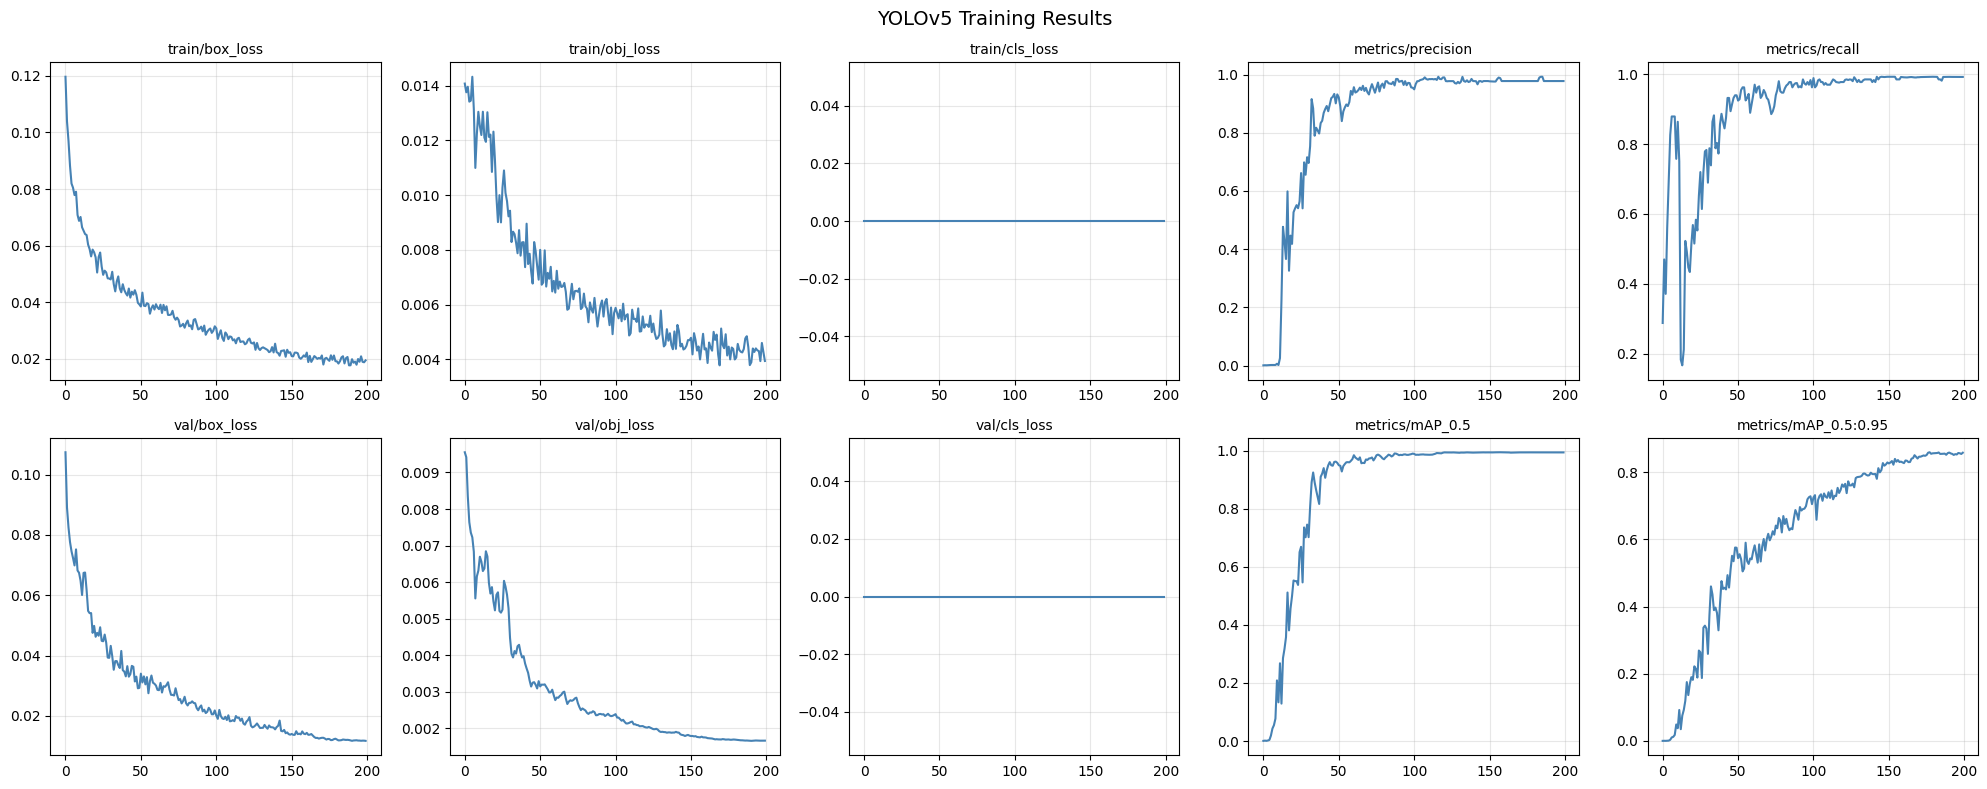


─── Final Metrics ──────────────────────
train/box_loss                : 0.0195
train/obj_loss                : 0.0039
train/cls_loss                : 0.0000
metrics/precision             : 0.9776
metrics/recall                : 0.9919
val/box_loss                  : 0.0118
val/obj_loss                  : 0.0017
val/cls_loss                  : 0.0000
metrics/mAP_0.5               : 0.9941
metrics/mAP_0.5:0.95          : 0.8580


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ✅ Correct path to results.csv
results_path = "/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/runs/train/golf_club_only44/results.csv"

# Check file exists
if not os.path.exists(results_path):
    print("File not found. Searching...")
    for root, dirs, files in os.walk("/content/drive/MyDrive/Ass3/YOLO_partc/yolov5/runs"):
        for f in files:
            if f == "results.csv":
                print(f"Found: {os.path.join(root, f)}")
else:
    print(f"Found: {results_path}")

# Load CSV
results = pd.read_csv(results_path)
results.columns = results.columns.str.strip()

print(f"Shape: {results.shape}")
print(results.tail(5))

# ─── Plot ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
metrics = [
    'train/box_loss', 'train/obj_loss', 'train/cls_loss',
    'metrics/precision', 'metrics/recall',
    'val/box_loss', 'val/obj_loss', 'val/cls_loss',
    'metrics/mAP_0.5', 'metrics/mAP_0.5:0.95'
]

for ax, col in zip(axes.flatten(), metrics):
    if col in results.columns:
        ax.plot(results[col], color="steelblue")
        ax.set_title(col, fontsize=10)
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f"{col} (not found)", fontsize=9, color="gray")
        ax.axis("off")

plt.suptitle("YOLOv5 Training Results", fontsize=14)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Ass3/training_results.png", dpi=150)
plt.show()

# ─── Summary Table ──────────────────────────────────────
print("\n─── Final Metrics ──────────────────────")
for col in metrics:
    if col in results.columns:
        print(f"{col:<30}: {results[col].iloc[-1]:.4f}")